### **Useful Packages**

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

import pryngles as pr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### **Considering Limb-Darkening**

In order to consider the *Limb-Darkening* effect, we define a scaling factor $\alpha$ for planet area. In this way, we compute the transit depth more accurately

$$\alpha = \frac{I^{(limb)}}{I^{(no-limb)}}$$

**Kepler 51, Limb Coeffs Source:** https://arxiv.org/html/2410.01625v2#abstract

##### **At Center**

In [4]:
rho = 0 # At Star center

# No Limb-Darkening
I_nlimb = pr.Science.limb_darkening(rho, cs = [0, 0])

# Considering Limb-Darkening
limb_cf = [0.296, 0.4] # https://arxiv.org/html/2410.01625v2#abstract
I_limb = pr.Science.limb_darkening(rho, cs = limb_cf)

print(f'Coefficients: [0, 0]\nLimb-Darkening: {I_nlimb}\n')

print(f'Coefficients: {limb_cf}\nLimb-Darkening: {I_limb}\n')

print(f'Scaling Factor: {I_limb/I_nlimb}')

Coefficients: [0, 0]
Limb-Darkening: 0.3183098861837907

Coefficients: [0.296, 0.4]
Limb-Darkening: 0.38136168472498955

Scaling Factor: 1.1980830670926539


##### **Over Star**

In [5]:
rhos = np.linspace(-1, 1, 1000) # Projected Distance over Star's Disk

# No Limb-Darkening
I_nlimb = pr.Science.limb_darkening(rhos, cs = [0, 0]) 

# Considering Limb-Darkening
limb_cf = [0.296, 0.4] # https://arxiv.org/html/2410.01625v2#abstract
I_limb = pr.Science.limb_darkening(rhos, cs = limb_cf)

# Scaling Factor
alphas = I_limb/I_nlimb


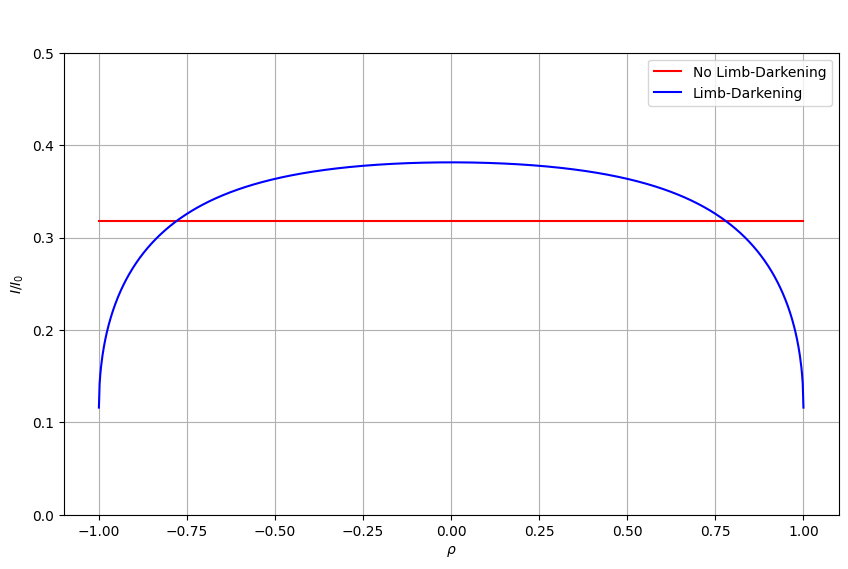

In [6]:
plt.figure(figsize = (10, 6))

plt.plot(rhos, I_nlimb, label = 'No Limb-Darkening', color = 'red')
plt.plot(rhos, I_limb, label = 'Limb-Darkening', color = 'blue')

plt.title('\n')
plt.xlabel(r'$\rho$')
plt.ylabel(r'$I/I_0$')

plt.legend()
plt.grid()

plt.ylim(0, 0.5)

plt.show()

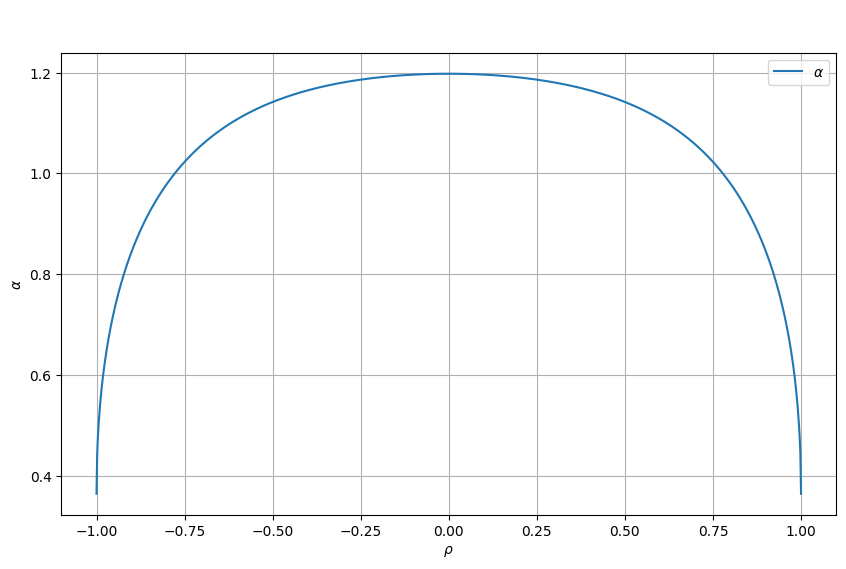

In [7]:
plt.figure(figsize = (10, 6))

plt.plot(rhos, I_limb/I_nlimb, label = r'$\alpha$')

plt.grid()
plt.legend()

plt.title('\n')
plt.xlabel(r'$\rho$')
plt.ylabel(r'$\alpha$')

plt.show()